# 1 - Retail Sales Forecasting - Time Series

<img src='https://www.evrensel.net/images/1280/upload/dosya/67185.jpg'>

Bu çalışmada perakende satış verileri üzerinden zaman serisi analizi yaparak gelecekteki satışları tahmin edeceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. Zaman serisi görselleştirme
6. Seasonal decomposition
7. SARIMAX modeli kurma
8. Tahmin
9. Sonuç


In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error


## 1. Veriyi Yükleme

In [2]:
# Bu bölümde zip dosyasını Google Drive içinden açıp çalışma alanına çıkaracağım.

In [3]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Retail Sales Forecasting Using SARIMAX.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]

Mounted at /content/drive


['.config',
 'drive',
 'sales_forecasting.ipynb',
 'retail_sales_mock_data.csv',
 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [4]:
# Bu bölümde csv dosyasını okuyup veri setinin yapısını inceleyeceğim.

In [5]:
df = pd.read_csv('/content/retail_sales_mock_data.csv')
df.head()

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0


In [6]:
df.shape

(48, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          48 non-null     object
 1   SalesAmount   48 non-null     int64 
 2   Promotion     48 non-null     int64 
 3   HolidayMonth  48 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.6+ KB


In [8]:
df.isnull().sum()

,0
Date,0
SalesAmount,0
Promotion,0
HolidayMonth,0


## 3. Veri Temizleme

In [9]:
# Bu bölümde tarih sütununu datetime tipine çevirip veri setini zaman serisi analizine uygun hale getireceğim.

In [10]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df.head()

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0


## 4. Feature Engineering

In [11]:
# Bu bölümde tarih sütununu index yapıp tahmin edilecek hedef değişkeni hazırlayacağım.

In [12]:
df = df.set_index('Date')
df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


In [13]:
series = df['SalesAmount']
series.head()

,SalesAmount
Date,
2020-01-01,12248
2020-02-01,13011
2020-03-01,12722
2020-04-01,14030
2020-05-01,7783


## 5. Zaman Serisi Görselleştirme

In [14]:
# Bu bölümde satış serisinin zaman içindeki değişimini görselleştireceğim.

In [15]:
fig = px.line(df.reset_index(), x='Date', y='SalesAmount', title='Retail Sales Over Time')
fig.show()

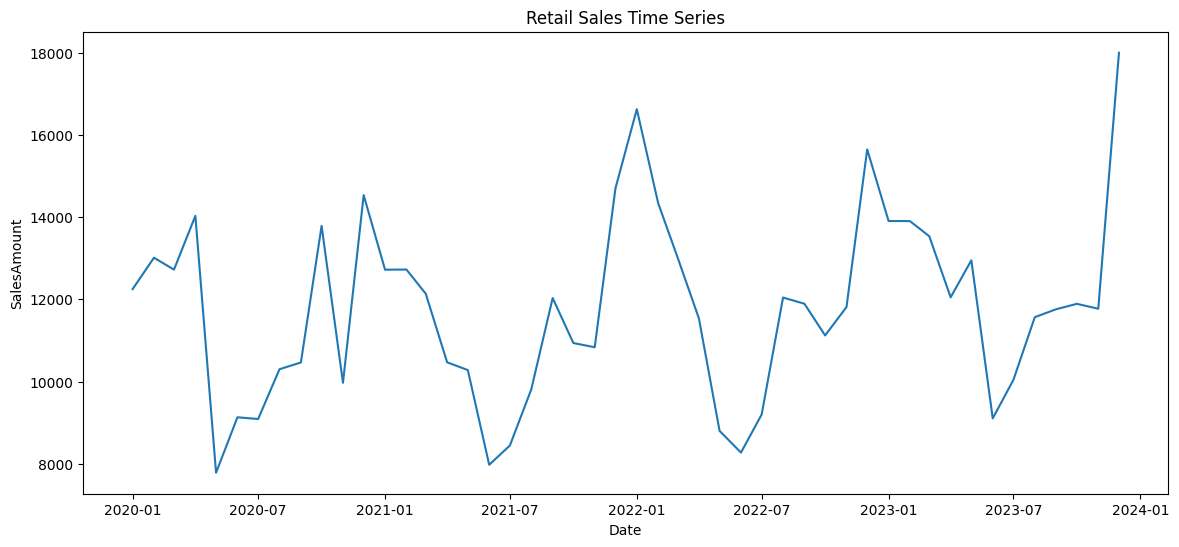

In [16]:
plt.figure(figsize=(14,6))
plt.plot(series)
plt.title('Retail Sales Time Series')
plt.xlabel('Date')
plt.ylabel('SalesAmount')
plt.show()

## 6. Seasonal Decomposition

In [17]:
# Bu bölümde zaman serisinin trend, seasonality ve residual bileşenlerini inceleyeceğim.

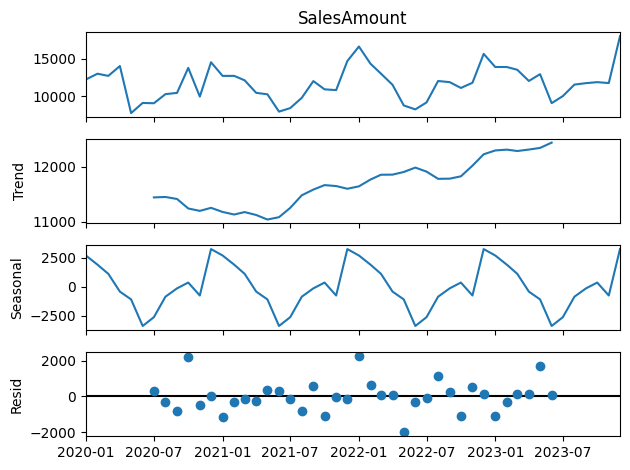

In [18]:
result = seasonal_decompose(series, model='additive', period=12)
result.plot()
plt.show()

## 7. SARIMAX Modeli Kurma

In [19]:
# Bu bölümde eğitim ve test verisini ayırıp SARIMAX modeli kuracağım.

In [20]:
train = series[:-6]
test = series[-6:]

train.shape, test.shape

((42,), (6,))

In [21]:
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit(disp=False)
print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



                                     SARIMAX Results                                      
Dep. Variable:                        SalesAmount   No. Observations:                   42
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -257.065
Date:                            Wed, 29 Apr 2026   AIC                            524.130
Time:                                    08:46:50   BIC                            530.966
Sample:                                01-01-2020   HQIC                           526.271
                                     - 06-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0429      0.934     -0.046      0.963      -1.874       1.789
ma.L1         -0.1762      0.971   

## 8. Tahmin

In [22]:
# Bu bölümde test dönemi için tahmin yapıp gerçek değerlerle karşılaştıracağım.

In [23]:
predictions = results.predict(start=len(train), end=len(train)+len(test)-1)
predictions.index = test.index

forecast_df = pd.DataFrame({
    'Actual': test,
    'Predicted': predictions
})
forecast_df

,Actual,Predicted
Date,,
2023-07-01,10042,10305.590935
2023-08-01,11566,12528.903239
2023-09-01,11759,13544.977011
2023-10-01,11890,12115.366667
2023-11-01,11770,12957.830052
2023-12-01,17996,16611.958634


In [24]:
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
print('MAE:', round(mae, 2))
print('RMSE:', round(rmse, 2))


MAE: 968.28
RMSE: 1122.77


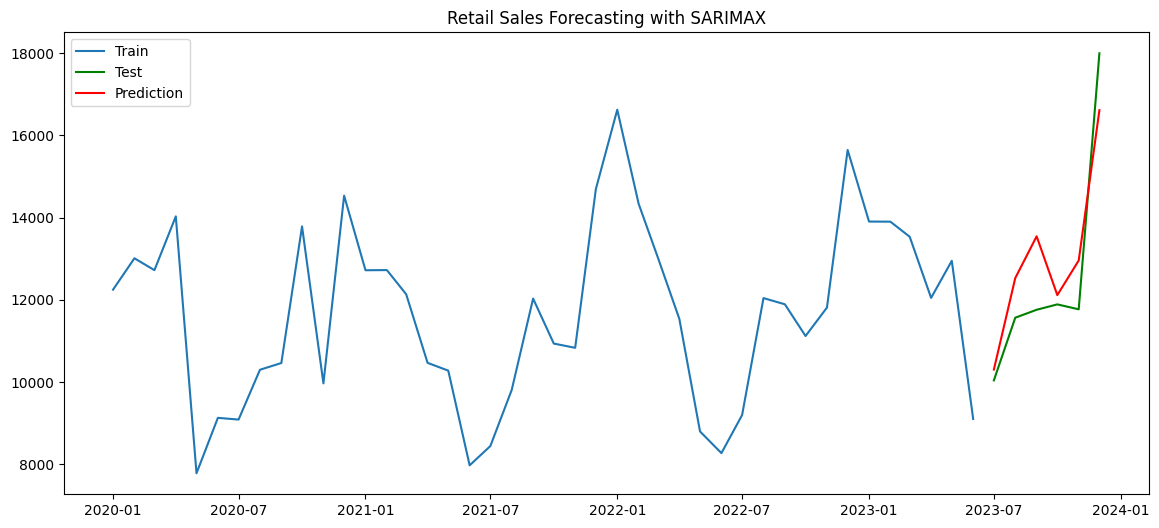

In [25]:
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='green')
plt.plot(predictions.index, predictions, label='Prediction', color='red')
plt.legend()
plt.title('Retail Sales Forecasting with SARIMAX')
plt.show()

## 9. Sonuç

Bu projede perakende satış tahmini için SARIMAX tabanlı bir time series modeli kullanıldı. Elde edilen sonuçlara göre model test dönemi için gelecek satış değerlerini tahmin etti ve 968.28 MAE ile 1122.77 RMSE değeri elde etti.
